<a href="https://colab.research.google.com/github/taroshima/22bds0246_EDA/blob/main/22BDS0246.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/countymurders.csv"
df = pd.read_csv(url)

print(df.head())


   rownames  arrests  countyid  density  popul  perc1019  perc2029  percblack  \
0         1      2.0      1001    54.05  32216     20.63     15.28      22.33   
1         2      3.0      1001    53.66  31984     20.19     15.55      22.07   
2         3      2.0      1001    53.75  32036     19.66     15.73      21.80   
3         4      7.0      1001    53.78  32056     19.10     15.88      21.53   
4         5      3.0      1001    53.91  32128     18.54     15.92      21.26   

   percmale  rpcincmaint  ...  rpcunemins  year  murders  murdrate  \
0     40.25       167.67  ...       29.16  1980        2  0.620810   
1     40.36       167.99  ...       43.92  1981        1  0.312656   
2     40.42       166.63  ...       71.41  1982        3  0.936446   
3     40.47       176.53  ...       72.22  1983        7  2.183679   
4     40.51       166.25  ...       40.36  1984        2  0.622510   

   arrestrate  statefips  countyfips  execs    lpopul  execrate  
0    0.620810          1  

In [ ]:
df.columns

Index(['rownames', 'arrests', 'countyid', 'density', 'popul', 'perc1019',
       'perc2029', 'percblack', 'percmale', 'rpcincmaint', 'rpcpersinc',
       'rpcunemins', 'year', 'murders', 'murdrate', 'arrestrate', 'statefips',
       'countyfips', 'execs', 'lpopul', 'execrate'],
      dtype='object')

In [ ]:
df.shape

(37349, 21)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rownames,37349.0,18675.000000,10781.871939,1.000000,9338.000000,18675.000000,28012.000000,3.734900e+04
arrests,36845.0,6.782250,50.128657,0.000000,0.000000,1.000000,3.000000,2.391000e+03
countyid,37349.0,32921.927173,15528.352966,1001.000000,20105.000000,36065.000000,48049.000000,5.604500e+04
density,37349.0,252.241067,1663.768484,0.050000,17.681580,44.240000,106.600000,5.405877e+04
popul,37349.0,89343.541219,271854.498963,85.000000,13144.000000,28792.000000,66480.000000,9.127751e+06
perc1019,37349.0,15.582640,1.973399,7.080000,14.320000,15.420000,16.730000,3.048458e+01
perc2029,37349.0,14.584615,3.696407,5.617244,12.301700,14.270000,16.200000,4.052000e+01
percblack,37349.0,7.823194,13.287067,0.000000,0.200000,1.450000,8.740000,8.627934e+01
percmale,37349.0,43.350958,3.717612,35.150000,40.900000,41.810000,45.870000,7.804000e+01
rpcincmaint,37346.0,165.450844,97.488961,5.490000,96.250000,145.147500,209.880000,1.306496e+03


In [ ]:
df.dtypes

,0
rownames,int64
arrests,float64
countyid,int64
density,float64
popul,int64
perc1019,float64
perc2029,float64
percblack,float64
percmale,float64
rpcincmaint,float64


## Null value analysis

In [ ]:
df.isna().sum()

,0
rownames,0
arrests,504
countyid,0
density,0
popul,0
perc1019,0
perc2029,0
percblack,0
percmale,0
rpcincmaint,3


In [ ]:
mean_arrests = df["arrests"].mean(skipna=True)
median_arrests = df["arrests"].median(skipna=True)

mean_arrestrate = df["arrestrate"].mean(skipna=True)
median_arrestrate = df["arrestrate"].median(skipna=True)

print(f"arrests mean: {mean_arrests:.2f}, median: {median_arrests:.2f}")
print(f"arrest rate mean: {mean_arrestrate:.2f}, median: {median_arrestrate:.2f}")


arrests mean: 6.78, median: 1.00
arrest rate mean: 0.51, median: 0.16


### Checking whther its better to fill NA with mean or median

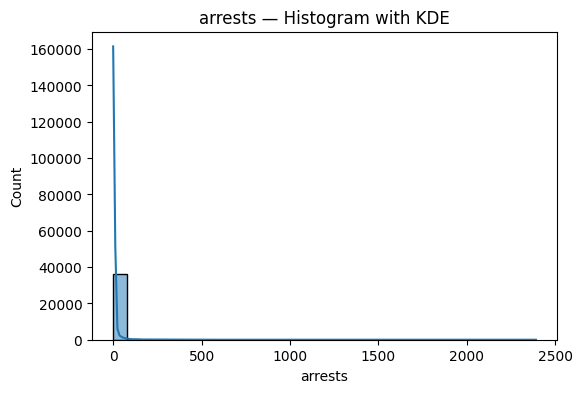

In [ ]:


plt.figure(figsize=(6,4))
sns.histplot(df["arrests"], kde=True, bins=30)
plt.title("arrests — Histogram with KDE")
plt.xlabel("arrests")
plt.ylabel("Count")
plt.show()


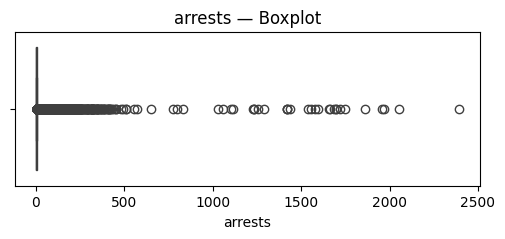

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["arrests"])
plt.title("arrests — Boxplot")
plt.show()


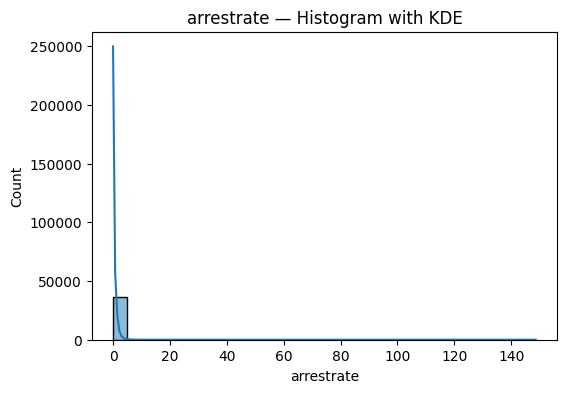

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["arrestrate"], kde=True, bins=30)
plt.title("arrestrate — Histogram with KDE")
plt.xlabel("arrestrate")
plt.ylabel("Count")
plt.show()


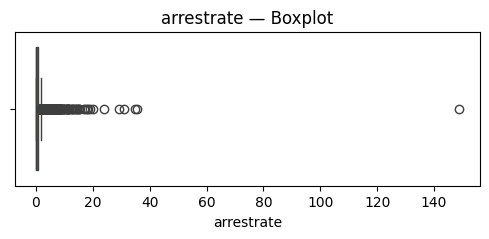

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["arrestrate"])
plt.title("arrestrate — Boxplot")
plt.show()


### As data is skewed we choose median

In [ ]:
df["arrests"] = df["arrests"].fillna(df["arrests"].median())
df["arrestrate"] = df["arrestrate"].fillna(df["arrestrate"].median())


In [ ]:
df.isna().sum()


,0
rownames,0
arrests,0
countyid,0
density,0
popul,0
perc1019,0
perc2029,0
percblack,0
percmale,0
rpcincmaint,3


In [ ]:
df = df.dropna()

In [ ]:
df.isna().sum()


,0
rownames,0
arrests,0
countyid,0
density,0
popul,0
perc1019,0
perc2029,0
percblack,0
percmale,0
rpcincmaint,0


### Checking for duplicate values

In [ ]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

df = df.drop_duplicates()


Duplicate rows: 0


In [ ]:
df.head().T

,0,1,2,3,4
rownames,1.00000,2.000000,3.000000,4.000000,5.000000
arrests,2.00000,3.000000,2.000000,7.000000,3.000000
countyid,1001.00000,1001.000000,1001.000000,1001.000000,1001.000000
density,54.05000,53.660000,53.750000,53.780000,53.910000
popul,32216.00000,31984.000000,32036.000000,32056.000000,32128.000000
perc1019,20.63000,20.190000,19.660000,19.100000,18.540000
perc2029,15.28000,15.550000,15.730000,15.880000,15.920000
percblack,22.33000,22.070000,21.800000,21.530000,21.260000
percmale,40.25000,40.360000,40.420000,40.470000,40.510000
rpcincmaint,167.67000,167.990000,166.630000,176.530000,166.250000


### Correcting skewed data

In [ ]:
df["log_arrests"] = np.log1p(df["arrests"])
df["log_arrestrate"] = np.log1p(df["arrestrate"])
df["log_murders"] = np.log1p(df["murders"])


In [ ]:
df = df.drop(['rownames'], axis = 1 )

## Univariate analysis

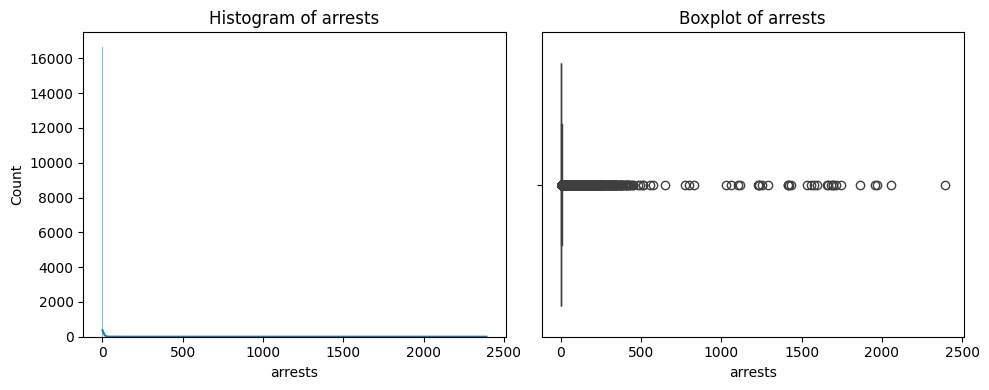

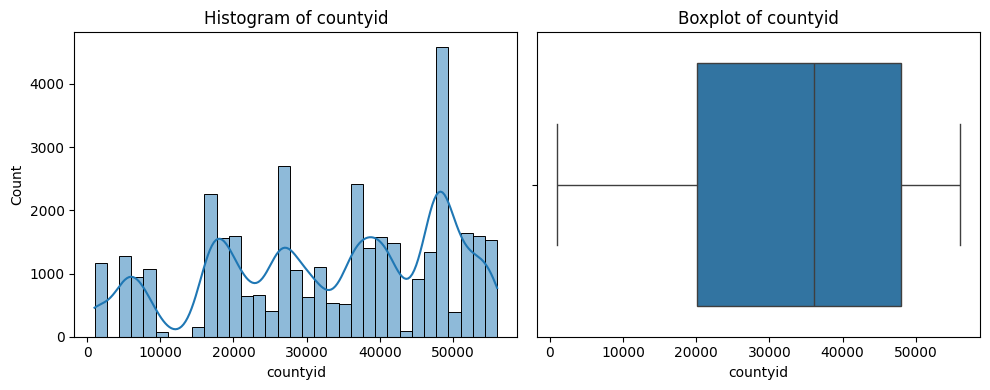

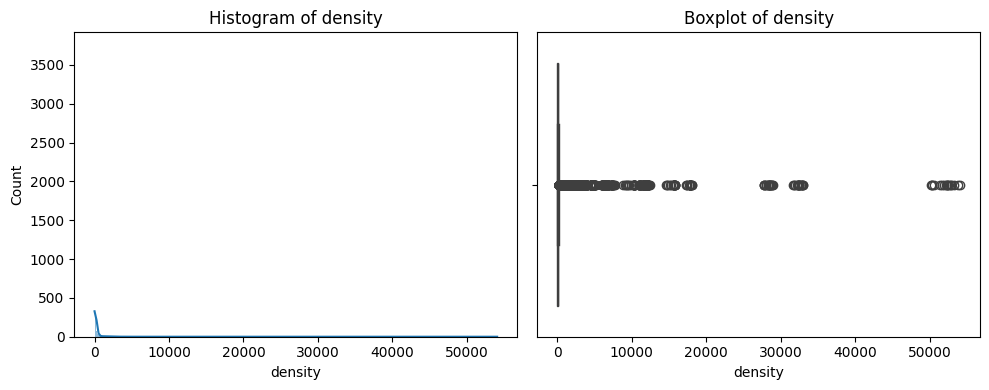

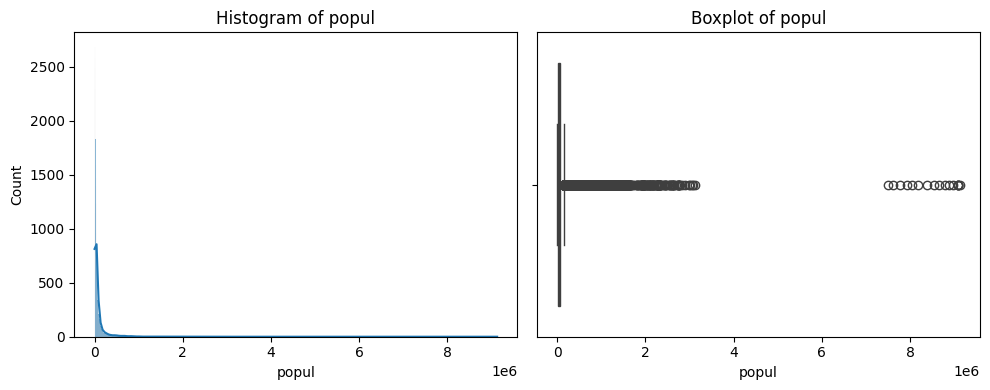

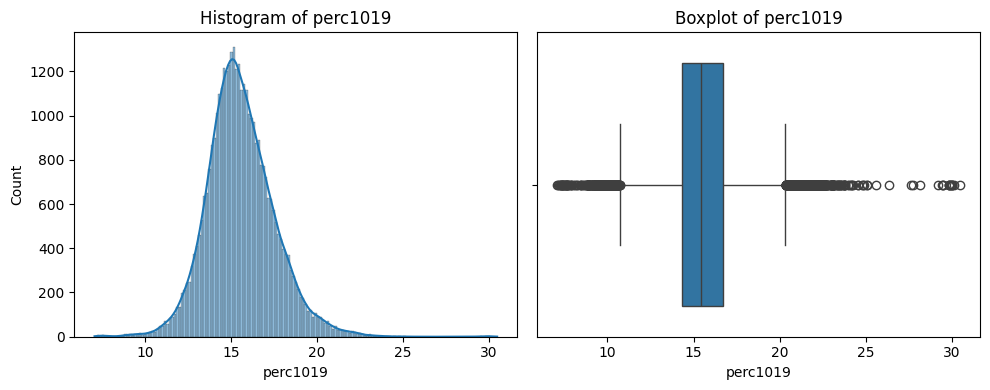

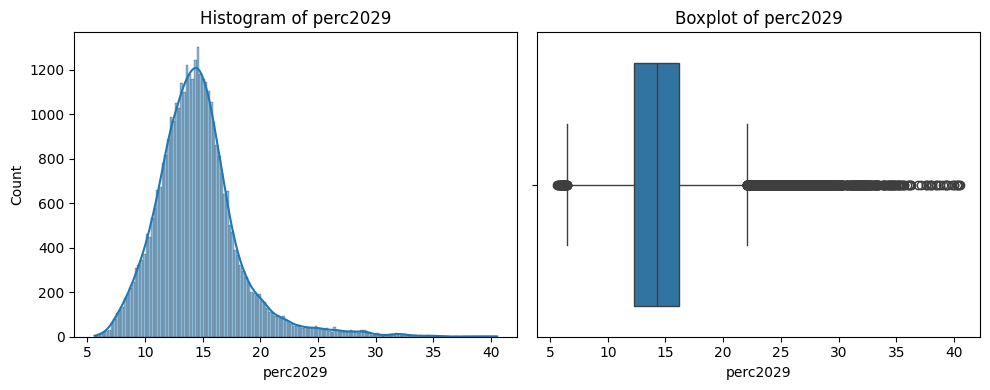

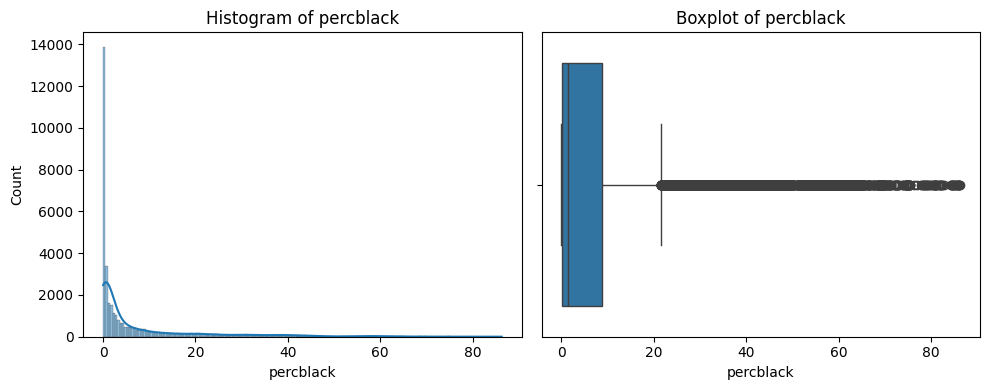

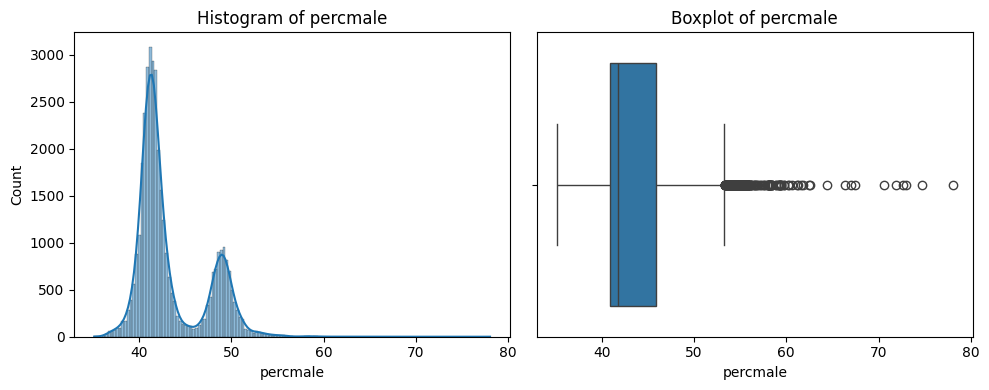

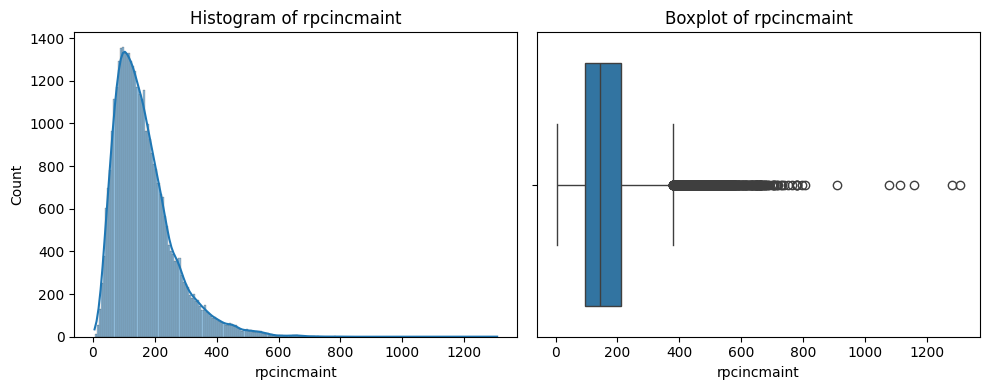

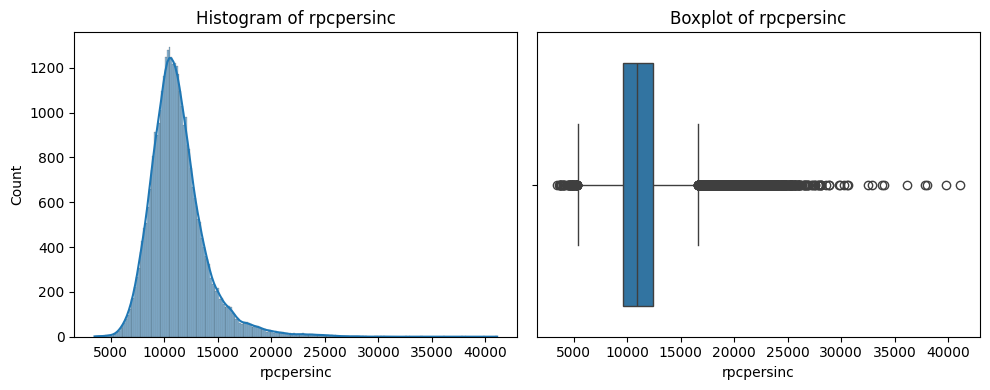

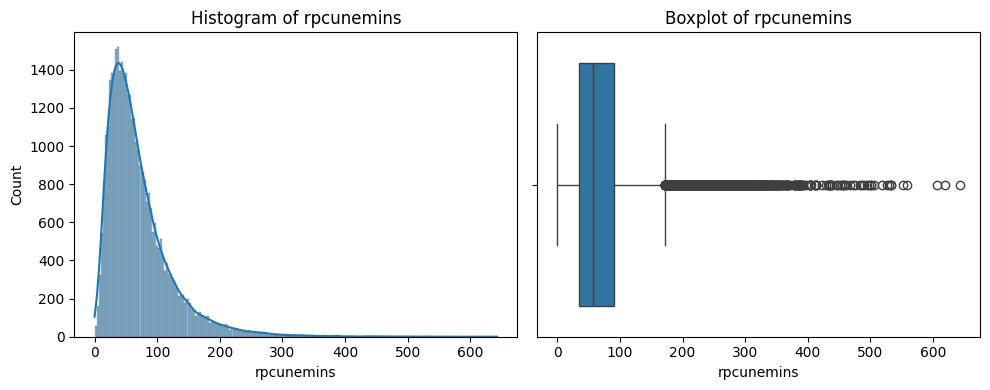

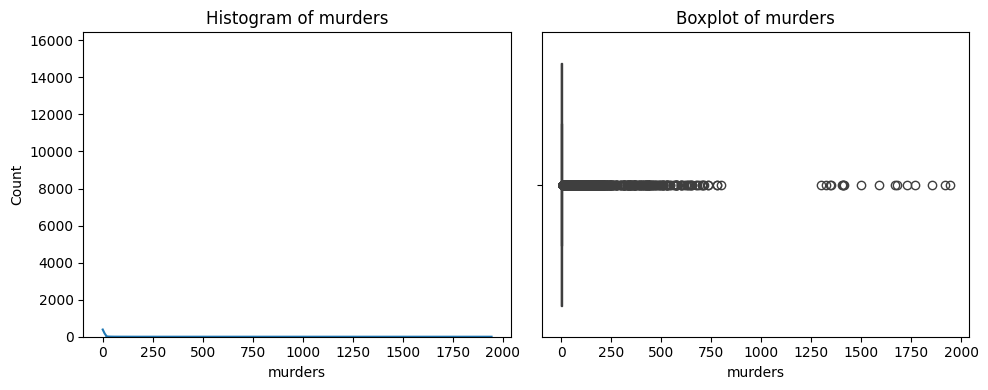

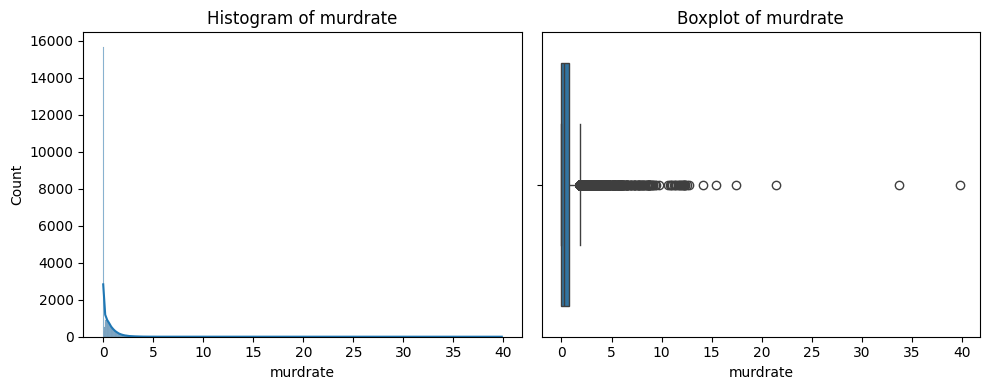

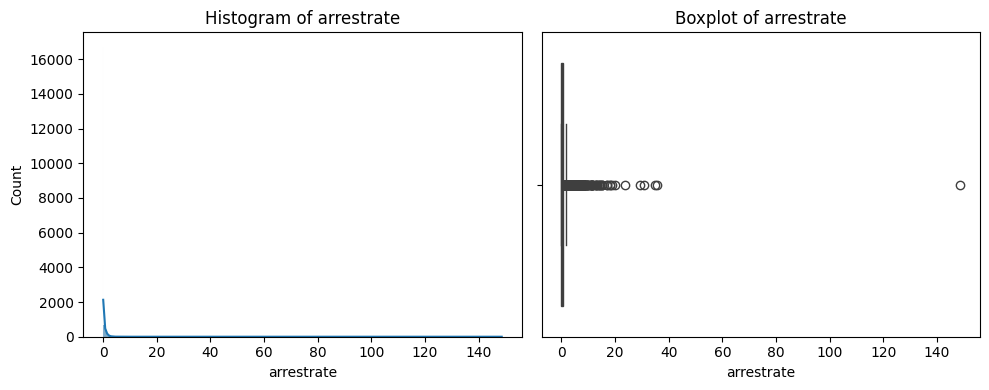

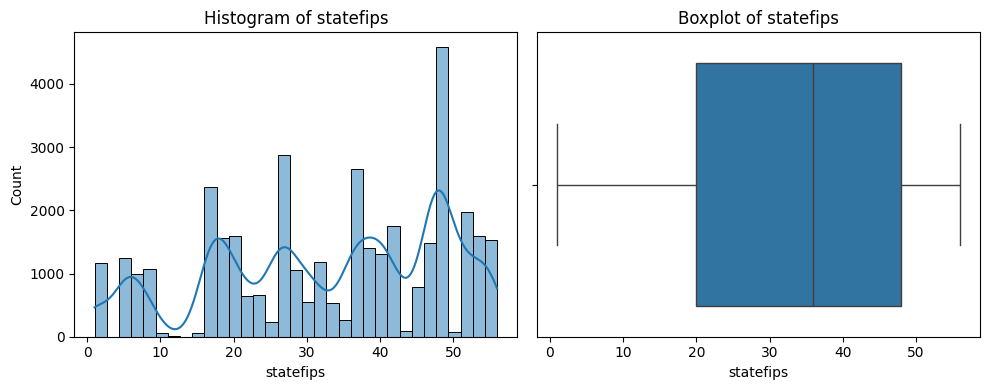

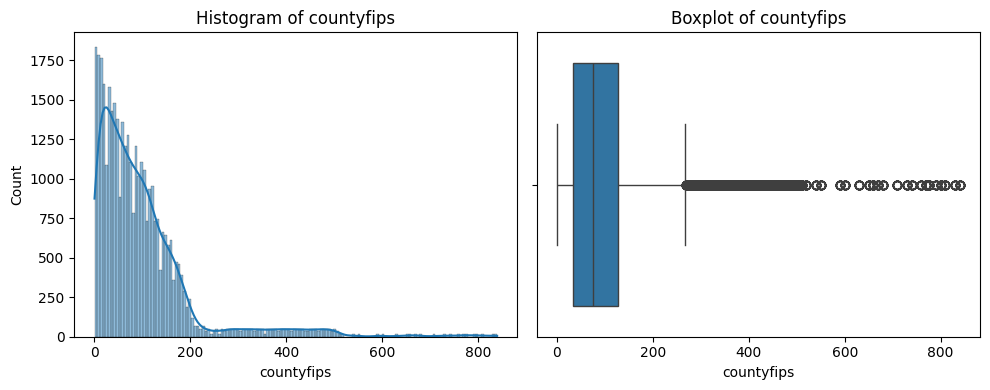

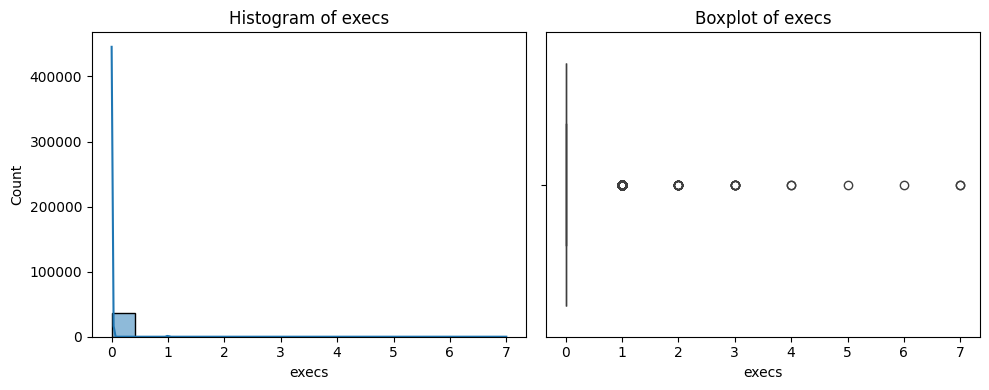

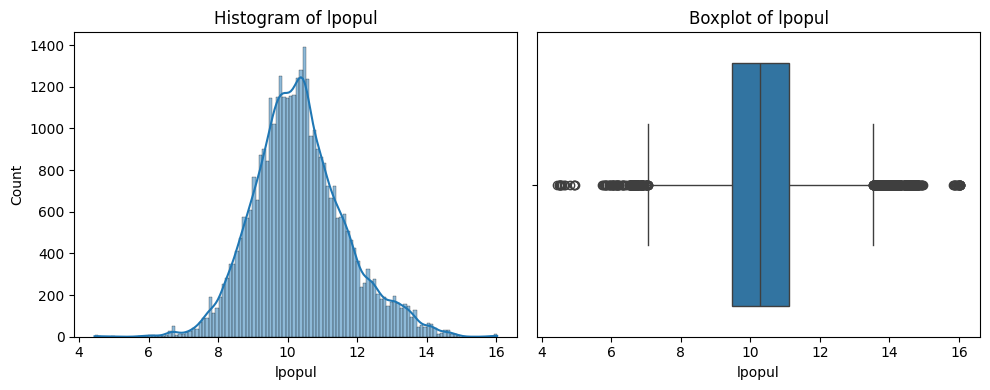

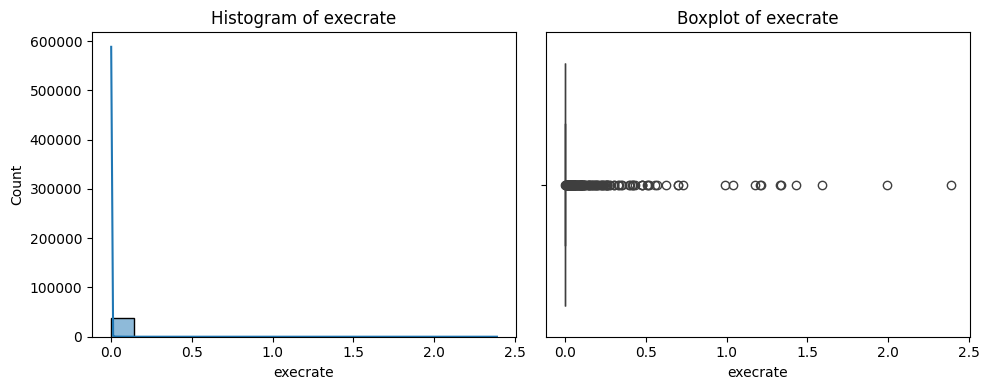

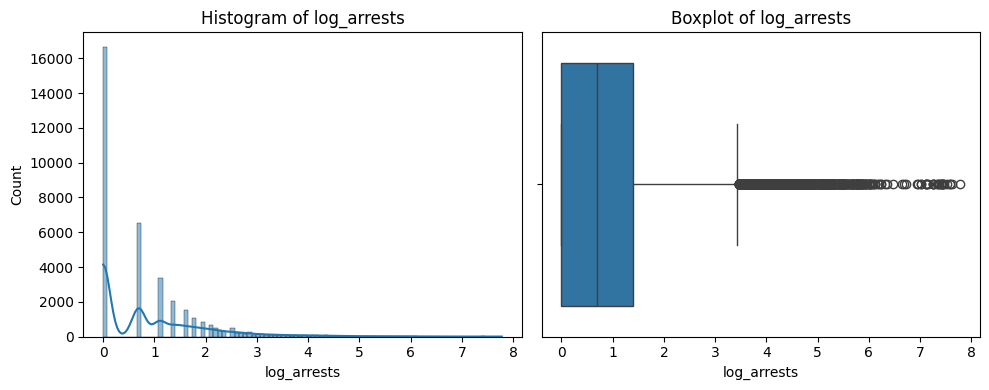

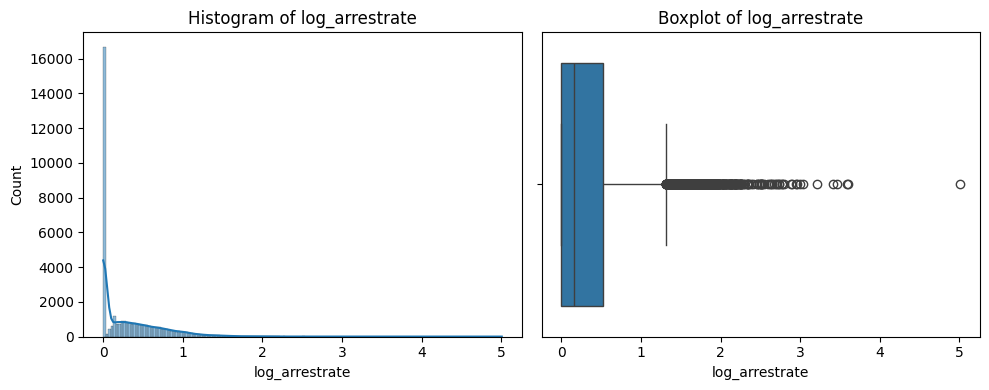

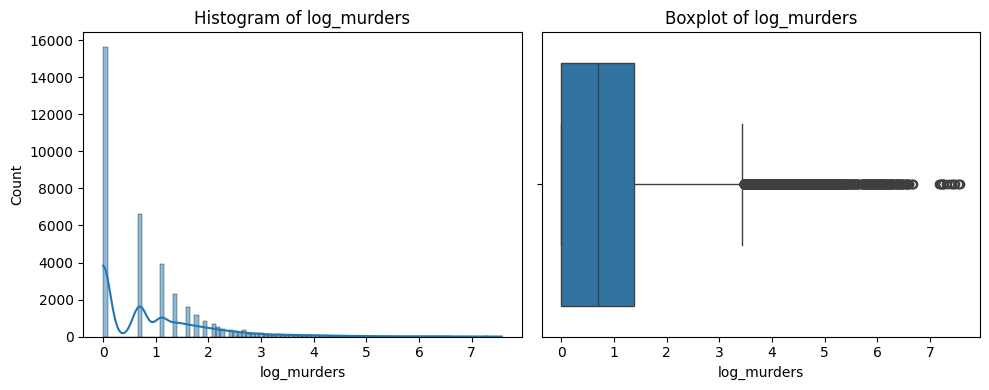

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['year'])
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


## Bivariate Analysis

<Figure size 1600x1200 with 0 Axes>

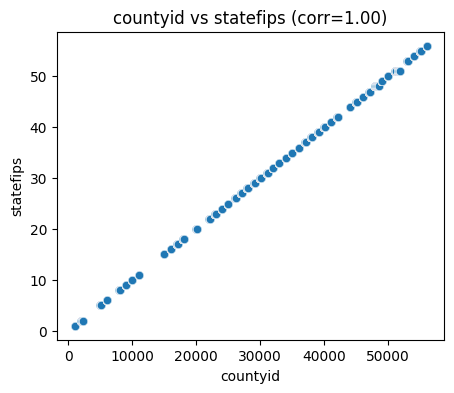

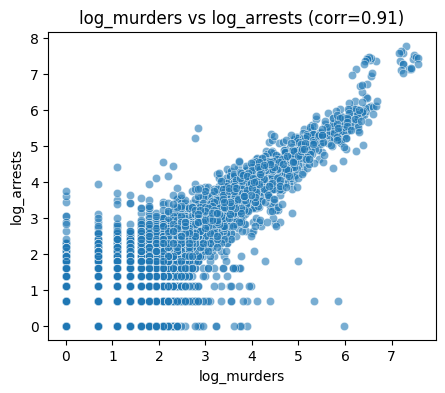

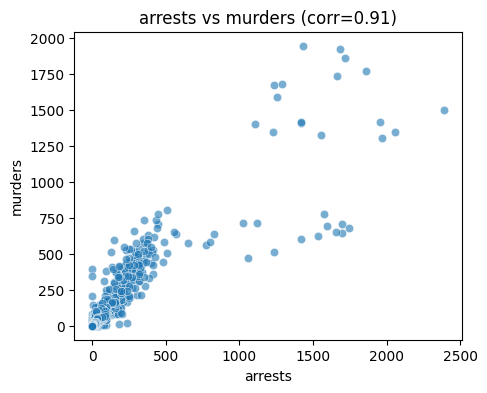

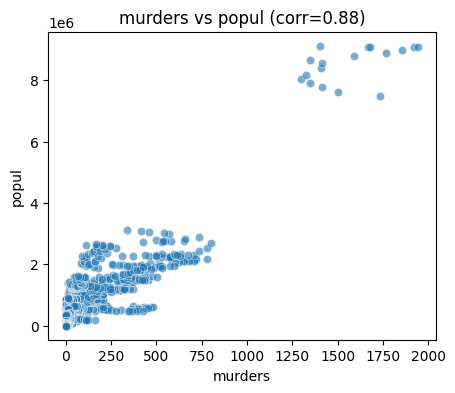

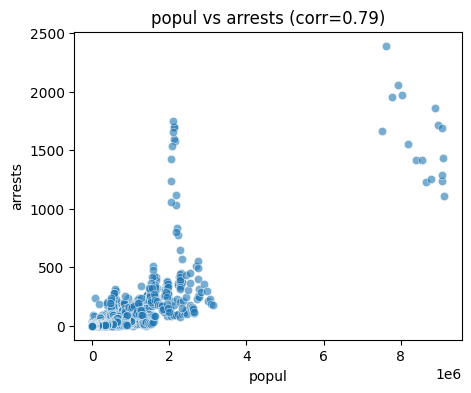

In [ ]:
plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr(method='pearson')

corr_pairs = corr.unstack().sort_values(key=abs, ascending=False).drop_duplicates()
corr_pairs = corr_pairs[abs(corr_pairs) < 1].head(5)

for pair, val in corr_pairs.items():
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df[pair[0]], y=df[pair[1]], alpha=0.6)
    plt.title(f"{pair[0]} vs {pair[1]} (corr={val:.2f})")
    plt.show()

## Multivariate Analysis

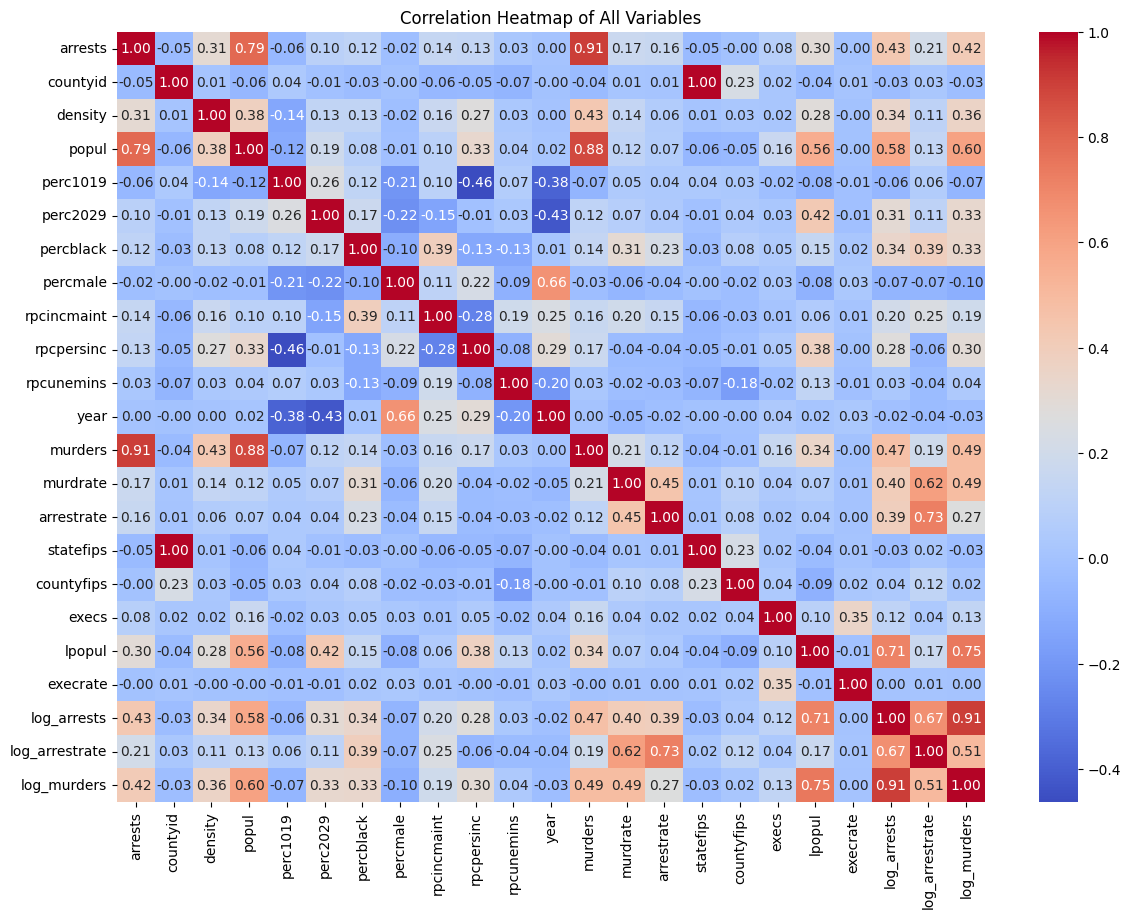

In [ ]:
# sns.pairplot(df)
# plt.suptitle("Pairplot of All Numerical Variables", y=1.02)
# plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of All Variables")
plt.show()


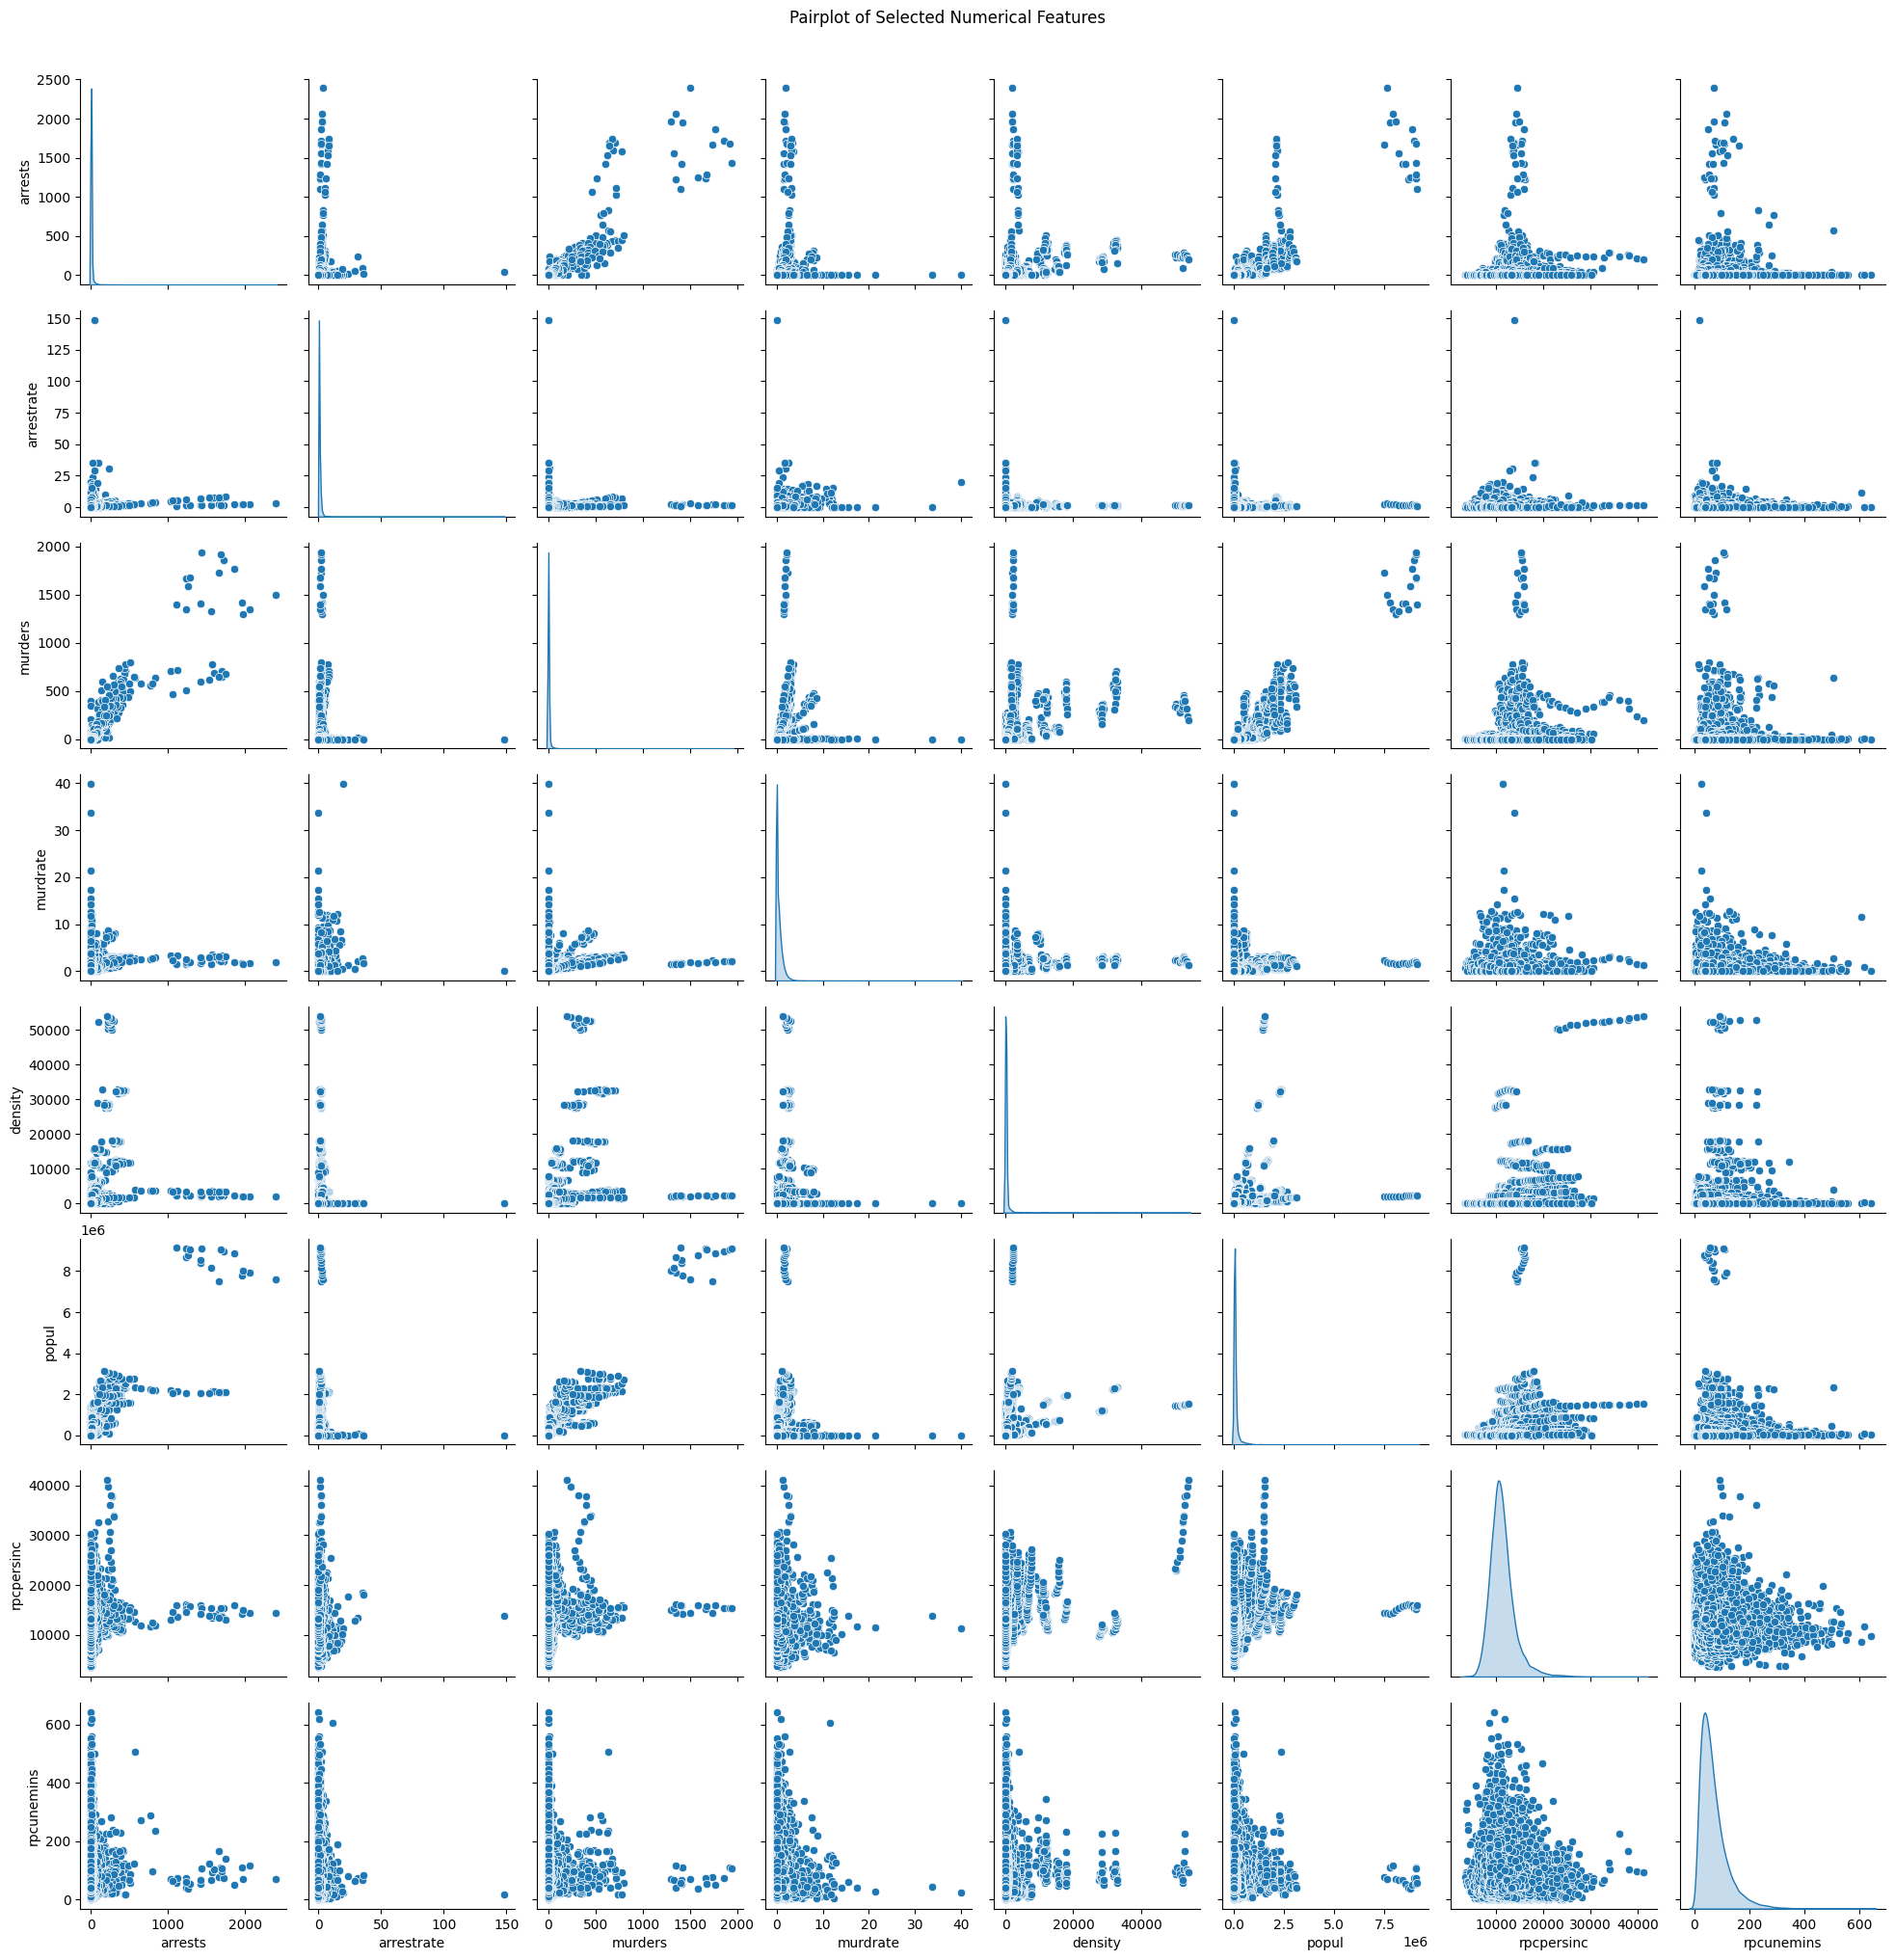

In [ ]:
some_features = [
    'arrests', 'arrestrate', 'murders', 'murdrate',
    'density', 'popul', 'rpcpersinc', 'rpcunemins'
]
sns.pairplot(df[some_features], diag_kind='kde')
plt.suptitle("Pairplot of Selected Numerical Features", y=1.02)
plt.show()




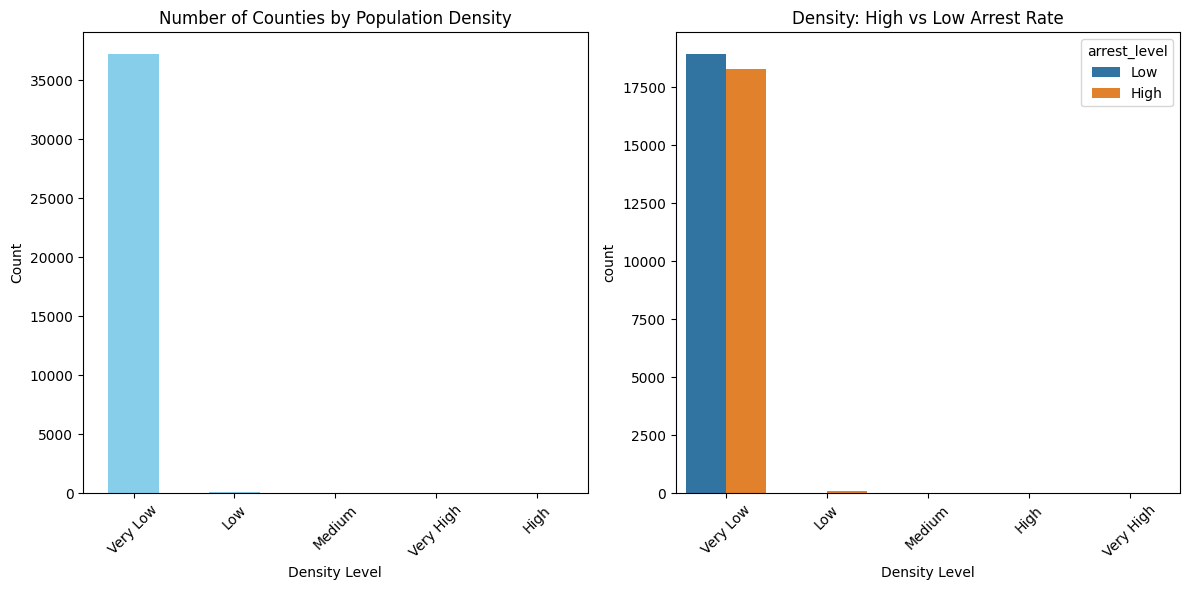

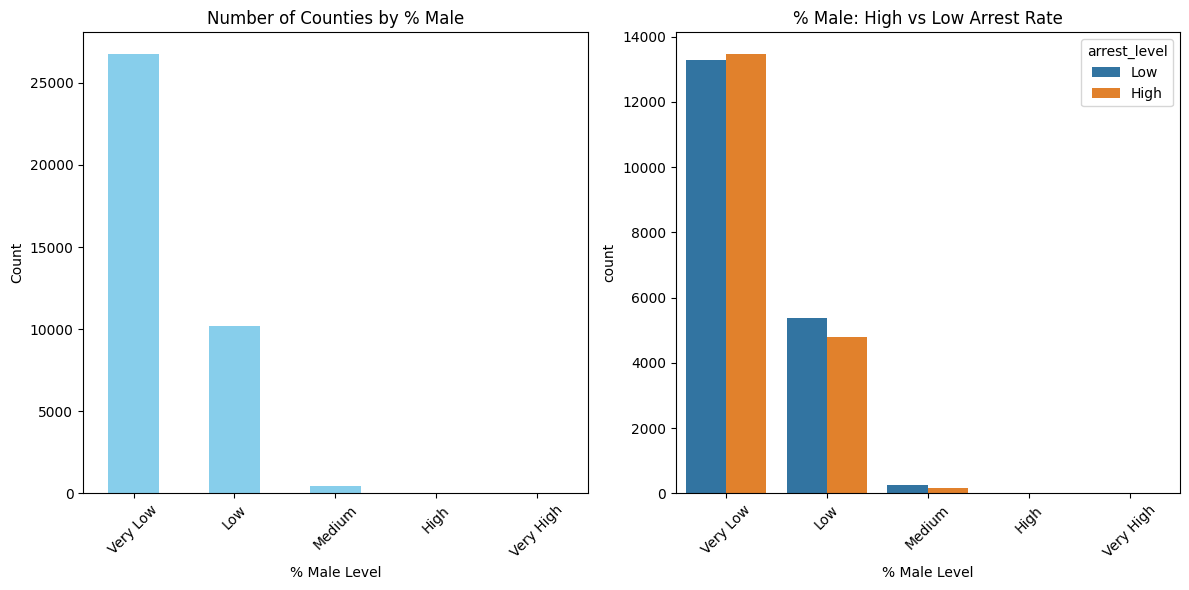

In [ ]:
df['arrest_level'] = pd.cut(df['arrestrate'], bins=[-float('inf'), df['arrestrate'].median(), float('inf')], labels=['Low', 'High'])

n_bins = 5
density_bins = np.linspace(df['density'].min(), df['density'].max(), n_bins + 1)
density_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['density_bins'] = pd.cut(df['density'], bins=density_bins, labels=density_labels, include_lowest=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
df['density_bins'].value_counts().plot.bar(color="skyblue", ax=ax[0])
ax[0].set_title("Number of Counties by Population Density")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("Density Level")
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x='density_bins', hue='arrest_level', data=df, ax=ax[1])
ax[1].set_title("Density: High vs Low Arrest Rate")
ax[1].set_xlabel("Density Level")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

percmale_bins = np.linspace(df['percmale'].min(), df['percmale'].max(), n_bins + 1)
percmale_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['percmale_bins'] = pd.cut(df['percmale'], bins=percmale_bins, labels=percmale_labels, include_lowest=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
df['percmale_bins'].value_counts().plot.bar(color="skyblue", ax=ax[0])
ax[0].set_title("Number of Counties by % Male")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("% Male Level")
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x='percmale_bins', hue='arrest_level', data=df, ax=ax[1])
ax[1].set_title("% Male: High vs Low Arrest Rate")
ax[1].set_xlabel("% Male Level")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
